# Objectif 2 - Prediction de la note

- **Type d'apprentissage** : regression supervisee
- **Cible** : `note_num` sur 20
- **Algorithmes utilises** :
  - `ridge_regression`
  - `random_forest_regressor`
  - `gradient_boosting_regressor`
  - `extra_trees_regressor`
- **Technique d'augmentation** : bootstrap controle avec bruit gaussien

Ce notebook contient directement les fonctions ML, le code des algorithmes, la phase d'entrainement, la comparaison des modeles et la sauvegarde du meilleur modele.


In [1]:
import sys
from pathlib import Path

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"Working directory: {Path.cwd()}")


Python executable: c:\Users\hedir\OneDrive\Desktop\ML_poulina\.conda\python.exe
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Working directory: c:\Users\hedir\OneDrive\Desktop\ML_poulina


In [2]:
%pip install pandas matplotlib seaborn scikit-learn joblib pyodbc


Note: you may need to restart the kernel to use updated packages.


## 1. Fonctions ML et code des algorithmes


In [3]:
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from notebook_sqlserver_loader import get_sqlserver_connection, load_ml_dataset_from_sqlserver


PROJECT_DIR = Path.cwd()
MODELS_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

OBJECTIF2_NUMERIC_FEATURES = [
    "critere_rang",
    "ponderation_num",
    "jour",
    "mois",
    "trimestre",
    "annee",
    "latitude",
    "longitude",
]

OBJECTIF2_CATEGORICAL_FEATURES = [
    "axe_evaluation",
    "criteres",
    "role_utilisateur",
    "utilisateur",
    "filiale",
    "secteur",
]

OBJECTIF2_FEATURE_COLUMNS = [
    *OBJECTIF2_NUMERIC_FEATURES,
    *OBJECTIF2_CATEGORICAL_FEATURES,
]


def load_base_dataset(project_dir: Path | None = None, threshold: float = 16.0) -> pd.DataFrame:
    root = (project_dir or PROJECT_DIR).resolve()
    return load_ml_dataset_from_sqlserver(project_dir=root, threshold=threshold).copy()


def _build_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0, keep_empty_features=True)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def _sanitize_feature_frame(
    frame: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str],
) -> pd.DataFrame:
    cleaned = frame.copy()

    for col in numeric_features:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    for col in categorical_features:
        if col in cleaned.columns:
            series = cleaned[col].astype("object")
            cleaned[col] = series.where(pd.notna(series), np.nan)

    return cleaned


def _bootstrap_regression_augment(
    df: pd.DataFrame,
    numeric_cols: list[str],
    target_col: str,
    multiplier: float = 1.0,
    noise_scale: float = 0.04,
    random_state: int = 42,
) -> pd.DataFrame:
    extra_count = int(len(df) * multiplier)
    if extra_count <= 0:
        return df.copy()

    rng = np.random.default_rng(random_state)
    sampled = df.sample(n=extra_count, replace=True, random_state=random_state).reset_index(drop=True).copy()

    for col in numeric_cols:
        if col not in sampled.columns or col == target_col:
            continue
        series = pd.to_numeric(sampled[col], errors="coerce")
        if int(series.notna().sum()) == 0:
            continue
        std = float(series.std(skipna=True) or 0.0)
        if std <= 0:
            continue
        noise = rng.normal(0.0, std * noise_scale, size=len(sampled))
        sampled[col] = (series.fillna(series.median()) + noise)

    sampled[target_col] = (
        pd.to_numeric(sampled[target_col], errors="coerce").fillna(df[target_col].median())
        + rng.normal(0.0, 0.35, size=len(sampled))
    ).clip(0.0, 20.0)
    sampled["audit_group"] = [f"boot_{index}" for index in range(len(sampled))]

    for col in ["critere_rang", "jour", "mois", "trimestre", "annee"]:
        if col in sampled.columns:
            sampled[col] = sampled[col].round().astype(int)

    if "ponderation_num" in sampled.columns:
        sampled["ponderation_num"] = pd.to_numeric(sampled["ponderation_num"], errors="coerce").fillna(0.0).clip(lower=0.0)

    return pd.concat([df, sampled], ignore_index=True, sort=False)


def build_objectif2_augmented_dataset(project_dir: Path | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = load_base_dataset(project_dir, threshold=16.0)
    augmented = _bootstrap_regression_augment(
        df=df,
        numeric_cols=OBJECTIF2_NUMERIC_FEATURES,
        target_col="note_num",
        multiplier=1.0,
        noise_scale=0.04,
        random_state=42,
    )
    return df, augmented


def _regression_models() -> dict[str, Any]:
    return {
        "ridge_regression": Ridge(alpha=1.0),
        "random_forest_regressor": RandomForestRegressor(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        ),
        "gradient_boosting_regressor": GradientBoostingRegressor(
            n_estimators=240,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
        "extra_trees_regressor": ExtraTreesRegressor(
            n_estimators=350,
            max_depth=14,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        ),
    }


def train_objectif2(project_dir: Path | None = None, save_model: bool = True) -> dict[str, Any]:
    root = (project_dir or PROJECT_DIR).resolve()
    df = load_base_dataset(root, threshold=16.0)
    augmented = _bootstrap_regression_augment(
        df=df,
        numeric_cols=OBJECTIF2_NUMERIC_FEATURES,
        target_col="note_num",
        multiplier=1.0,
        noise_scale=0.04,
        random_state=42,
    )

    X = _sanitize_feature_frame(
        augmented[OBJECTIF2_FEATURE_COLUMNS].copy(),
        numeric_features=OBJECTIF2_NUMERIC_FEATURES,
        categorical_features=OBJECTIF2_CATEGORICAL_FEATURES,
    )
    y = augmented["note_num"].astype(float)
    preprocessor = _build_preprocessor(OBJECTIF2_NUMERIC_FEATURES, OBJECTIF2_CATEGORICAL_FEATURES)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "neg_mae": "neg_mean_absolute_error",
        "neg_rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    }

    rows: list[dict[str, Any]] = []
    trained_pipelines: dict[str, Pipeline] = {}
    for name, estimator in _regression_models().items():
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("regressor", estimator),
            ]
        )
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=1)
        rows.append(
            {
                "modele": name,
                "mae": float(-np.mean(scores["test_neg_mae"])),
                "rmse": float(-np.mean(scores["test_neg_rmse"])),
                "r2": float(np.mean(scores["test_r2"])),
            }
        )
        trained_pipelines[name] = pipeline

    comparison = pd.DataFrame(rows).sort_values(["r2", "mae"], ascending=[False, True]).reset_index(drop=True)
    best_model_name = str(comparison.iloc[0]["modele"])
    best_model = trained_pipelines[best_model_name]
    best_model.fit(X, y)

    if save_model:
        joblib.dump(best_model, MODELS_DIR / "objectif2_note.joblib")
        comparison.to_csv(OUTPUTS_DIR / "objectif2_comparaison_modeles_augmented.csv", index=False)

    return {
        "comparison": comparison,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "base_rows": len(df),
        "augmented_rows": len(augmented),
    }


def prediction_smoke_test(model: Pipeline, sample_frame: pd.DataFrame) -> pd.Series:
    return pd.Series(
        model.predict(
            _sanitize_feature_frame(
                sample_frame[OBJECTIF2_FEATURE_COLUMNS].copy(),
                numeric_features=OBJECTIF2_NUMERIC_FEATURES,
                categorical_features=OBJECTIF2_CATEGORICAL_FEATURES,
            )
        )
    )


with get_sqlserver_connection(PROJECT_DIR) as connection:
    cursor = connection.cursor()
    cursor.execute("SELECT DB_NAME(), @@SERVERNAME")
    print("Connexion active vers :", cursor.fetchone())


Connexion active vers : ('stage_db', 'hedire\\MSSQLSERVER05')


## 2. Chargement des donnees depuis SQL Server


In [4]:
df_base, df_aug = build_objectif2_augmented_dataset(PROJECT_DIR)

print("Shape base :", df_base.shape)
print("Shape apres data augmentation :", df_aug.shape)
print("Statistiques note avant :")
print(df_base["note_num"].describe().round(3))
print("Statistiques note apres :")
print(df_aug["note_num"].describe().round(3))

display(df_base.head())


Shape base : (423, 20)
Shape apres data augmentation : (846, 20)
Statistiques note avant :
count    423.000
mean      14.255
std        5.122
min        0.000
25%       12.000
50%       15.000
75%       18.000
max       20.000
Name: note_num, dtype: float64
Statistiques note apres :
count    846.000
mean      14.227
std        5.134
min        0.000
25%       12.000
50%       15.086
75%       18.000
max       20.000
Name: note_num, dtype: float64


,pk_evaluation,id_eval,audit_group,critere_rang,axe_evaluation,criteres,note_num,ponderation_num,non_conforme,niveau_performance,jour,mois,trimestre,annee,role_utilisateur,utilisateur,filiale,secteur,latitude,longitude
0,10509,110001,110001,1,Hygi?ne,Propret? des zones,6.0,5.0,1,faible,1,1,1,2026,user,ahmed ben ahmed,Gipa,Agro,<NA>,<NA>
1,10510,110001,110001,2,Proc?d?,Respect des param?tres,8.0,4.0,1,faible,1,1,1,2026,user,ahmed ben ahmed,Gipa,Agro,<NA>,<NA>
2,10511,110001,110001,3,Tra?abilit?,Enregistrements,7.0,3.0,1,faible,1,1,1,2026,user,ahmed ben ahmed,Gipa,Agro,<NA>,<NA>
3,10512,110002,110002,1,Hygi?ne,Propret? des zones,14.0,5.0,1,moyen,1,3,1,2026,user,ahmed taha,Agromed,Agro,<NA>,<NA>
4,10513,110002,110002,2,Proc?d?,Respect des param?tres,15.0,4.0,1,moyen,1,3,1,2026,user,ahmed taha,Agromed,Agro,<NA>,<NA>


## 3. Visualisation de la distribution des notes


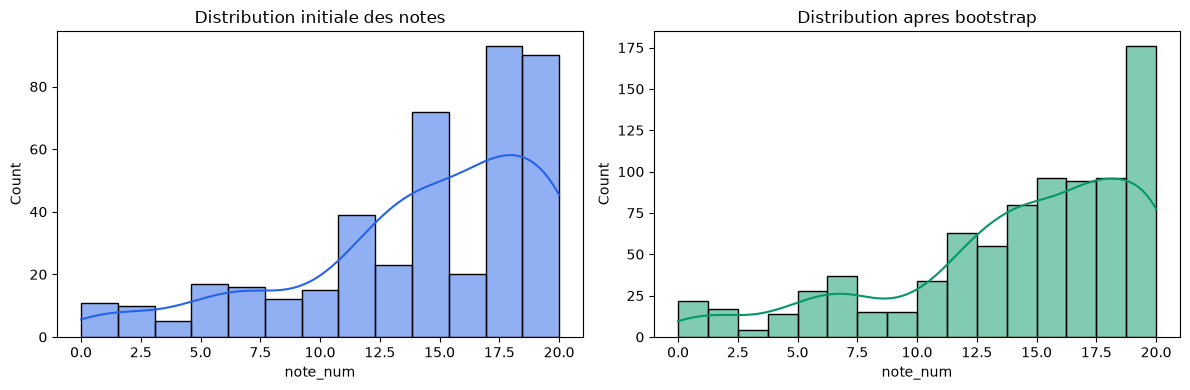

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_base["note_num"], kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribution initiale des notes")

sns.histplot(df_aug["note_num"], kde=True, ax=axes[1], color="#059669")
axes[1].set_title("Distribution apres bootstrap")

plt.tight_layout()
plt.show()


## 4. Entrainement, comparaison des modeles et sauvegarde


In [6]:
result_obj2 = train_objectif2(project_dir=PROJECT_DIR, save_model=True)
comparison_obj2 = result_obj2["comparison"].copy()
comparison_obj2 = comparison_obj2.assign(
    rang_global=range(1, len(comparison_obj2) + 1)
)[["rang_global", "modele", "mae", "rmse", "r2"]]

display(comparison_obj2.round(4))


,rang_global,modele,mae,rmse,r2
0,1,random_forest_regressor,2.9012,4.4787,0.2352
1,2,gradient_boosting_regressor,3.0375,4.4867,0.2319
2,3,extra_trees_regressor,2.8098,4.4958,0.2274
3,4,ridge_regression,3.4681,4.7403,0.1425


In [7]:
best_model_path = MODELS_DIR / "objectif2_note.joblib"
best_model = joblib.load(best_model_path)

print("Meilleur modele :", result_obj2["best_model_name"])
print("Modele sauvegarde dans :", best_model_path)
print(comparison_obj2.round(4))


Meilleur modele : random_forest_regressor
Modele sauvegarde dans : c:\Users\hedir\OneDrive\Desktop\ML_poulina\models\objectif2_note.joblib
   rang_global                       modele     mae    rmse      r2
0            1      random_forest_regressor  2.9012  4.4787  0.2352
1            2  gradient_boosting_regressor  3.0375  4.4867  0.2319
2            3        extra_trees_regressor  2.8098  4.4958  0.2274
3            4             ridge_regression  3.4681  4.7403  0.1425


## 4.1 Visualisation comparative des algorithmes


C:\Users\hedir\AppData\Local\Temp\ipykernel_12904\65694700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_obj2, x="modele", y="mae", ax=axes[0], palette="Blues_d")
C:\Users\hedir\AppData\Local\Temp\ipykernel_12904\65694700.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_obj2, x="modele", y="rmse", ax=axes[1], palette="Greens_d")
C:\Users\hedir\AppData\Local\Temp\ipykernel_12904\65694700.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_obj2, x="modele", y="r2", ax=axes[2], palette="

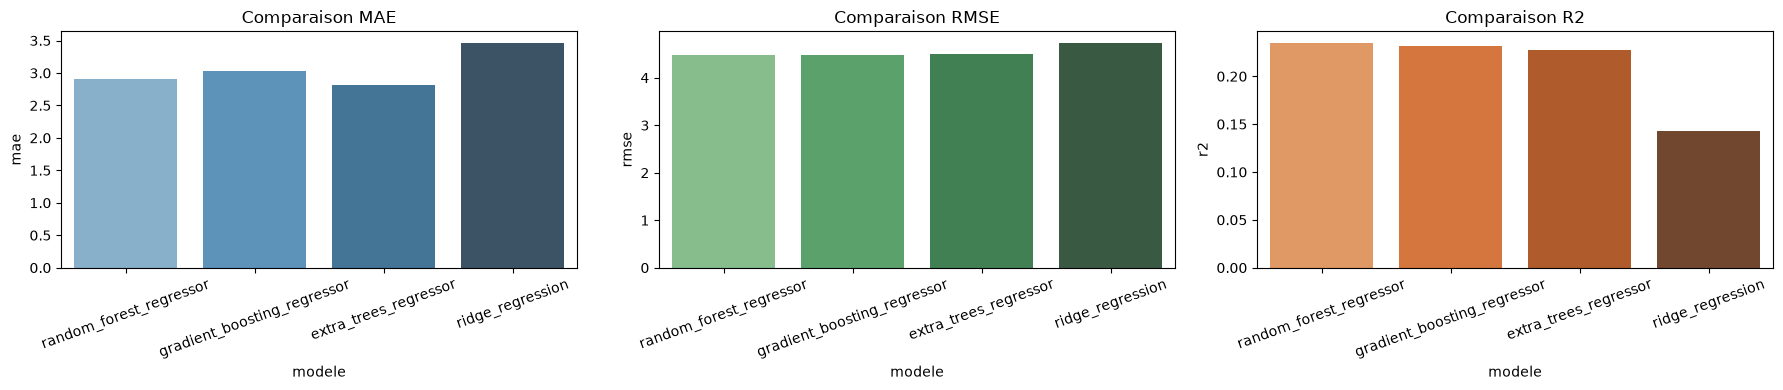

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=comparison_obj2, x="modele", y="mae", ax=axes[0], palette="Blues_d")
axes[0].set_title("Comparaison MAE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=comparison_obj2, x="modele", y="rmse", ax=axes[1], palette="Greens_d")
axes[1].set_title("Comparaison RMSE")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=comparison_obj2, x="modele", y="r2", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Comparaison R2")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 5. Test rapide du modele deploye


In [9]:
sample_predictions = prediction_smoke_test(best_model, df_base.head(5))
pd.DataFrame(
    {
        "critere_rang": df_base.head(5)["critere_rang"].tolist(),
        "filiale": df_base.head(5)["filiale"].tolist(),
        "note_reelle": df_base.head(5)["note_num"].tolist(),
        "note_predite": sample_predictions.round(2).tolist(),
    }
)


,critere_rang,filiale,note_reelle,note_predite
0,1,Gipa,6.0,7.73
1,2,Gipa,8.0,7.86
2,3,Gipa,7.0,8.53
3,1,Agromed,14.0,13.27
4,2,Agromed,15.0,13.50
